Import the libraries

In [ ]:
# Import core libraries for data handling
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Sampling techniques for handling class imbalance
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

Load the dataset

In [ ]:
# Load the credit card fraud dataset
df = pd.read_csv("/content/creditcard.csv")

# Display first few rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Take a look into the dataset: Inspection

In [ ]:
# Check dataset shape and structure
print("Dataset Shape:", df.shape)

# Check data types and missing values
df.info()

Dataset Shape: (284807, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-n

Check the data distribution: whether imbalanced or not

Class
0    284315
1       492
Name: count, dtype: int64


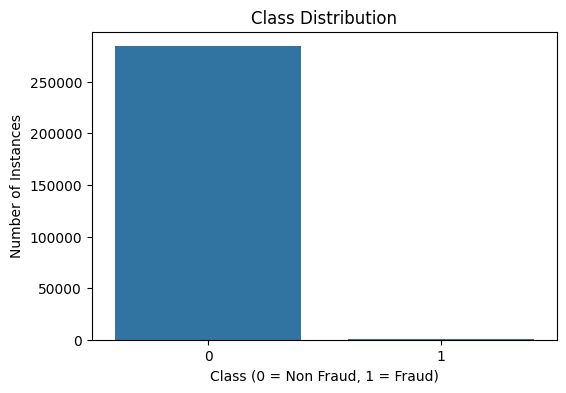

In [ ]:
# Count the number of instances for each class
class_counts = df['Class'].value_counts()

print(class_counts)

# Visualize the imbalance
plt.figure(figsize=(6,4))
sns.barplot(x=class_counts.index, y=class_counts.values)

plt.title("Class Distribution")
plt.xlabel("Class (0 = Non Fraud, 1 = Fraud)")
plt.ylabel("Number of Instances")
plt.show()

Separate Features and Target

In [ ]:
# Separate input features and target variable
X = df.drop('Class', axis=1)
y = df['Class']

Train Test Split

In [ ]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (227845, 30)
Testing samples: (56962, 30)


Train Logistic Regression on Imbalanced Data

In [ ]:
# Create Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Classification report as model evaluation

In [ ]:
# Print classification report
print("Classification Report (Imbalanced Data):")

print(classification_report(y_test, y_pred))

Classification Report (Imbalanced Data):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.69      0.76        98

    accuracy                           1.00     56962
   macro avg       0.92      0.85      0.88     56962
weighted avg       1.00      1.00      1.00     56962



see high accuracy but poor recall for fraud, showing why accuracy is misleading in imbalanced datasets.

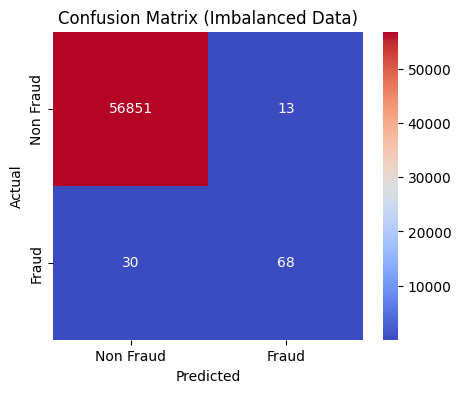

In [ ]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='coolwarm',
    xticklabels=['Non Fraud','Fraud'],
    yticklabels=['Non Fraud','Fraud']
)

plt.title("Confusion Matrix (Imbalanced Data)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Applying SMote!!: SMOTE creates synthetic minority samples instead of duplicating them.

In [ ]:
# SMOTE generates synthetic fraud samples

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Check new class distribution
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


Train Logistic Regression After SMOTE

In [ ]:
# Train logistic regression on SMOTE balanced data

model_smote = LogisticRegression(max_iter=1000)

model_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = model_smote.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Now check the evaluation

In [ ]:
print("Classification Report (After SMOTE):")

print(classification_report(y_test, y_pred_smote))

Classification Report (After SMOTE):
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.12      0.90      0.21        98

    accuracy                           0.99     56962
   macro avg       0.56      0.94      0.60     56962
weighted avg       1.00      0.99      0.99     56962



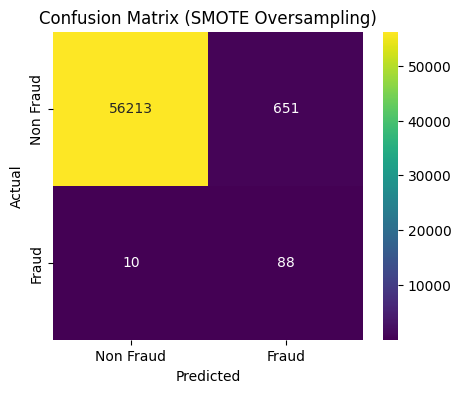

In [ ]:
cm_smote = confusion_matrix(y_test, y_pred_smote)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_smote,
    annot=True,
    fmt='d',
    cmap='viridis',
    xticklabels=['Non Fraud','Fraud'],
    yticklabels=['Non Fraud','Fraud']
)

plt.title("Confusion Matrix (SMOTE Oversampling)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Apply Random Undersampling: Undersampling removes majority samples, which can sometimes lead to loss of useful information.

In [ ]:
# Undersampling reduces majority class samples

undersample = RandomUnderSampler(random_state=42)

X_train_under, y_train_under = undersample.fit_resample(X_train, y_train)

print("Before Undersampling:")
print(y_train.value_counts())

print("\nAfter Undersampling:")
print(y_train_under.value_counts())

Before Undersampling:
Class
0    227451
1       394
Name: count, dtype: int64

After Undersampling:
Class
0    394
1    394
Name: count, dtype: int64


Same Model Training

In [ ]:
model_under = LogisticRegression(max_iter=1000)

model_under.fit(X_train_under, y_train_under)

y_pred_under = model_under.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Evaluation

In [ ]:
print("Classification Report (After Undersampling):")

print(classification_report(y_test, y_pred_under))

Classification Report (After Undersampling):
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     56864
           1       0.04      0.92      0.07        98

    accuracy                           0.96     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.96      0.98     56962



Why This Happens in Your Case

In the undersampling or oversampling of the dataset:

The dataset becomes very small or large

Feature values have different scales

Logistic Regression optimization becomes harder

Therefore the solver hits the iteration limit.

**Add Feature Scaling using StandardScaler**

Logistic Regression works much better with scaled features.

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
# Load the credit card fraud dataset

df = pd.read_csv("/content/creditcard.csv")

# Display first 5 rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# Separate input features and target variable

X = df.drop('Class', axis=1)
y = df['Class']

In [ ]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (227845, 30)
Testing samples: (56962, 30)


**Here comes the Feature Scaling**

In [ ]:
# Logistic Regression performs better when features are scaled

scaler = StandardScaler()

# Fit scaler only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply same transformation to test data
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Train logistic regression on imbalanced dataset

model = LogisticRegression(max_iter=5000)

model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

In [ ]:
print("Classification Report (Imbalanced Data)\n")

print(classification_report(y_test, y_pred))

Classification Report (Imbalanced Data)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



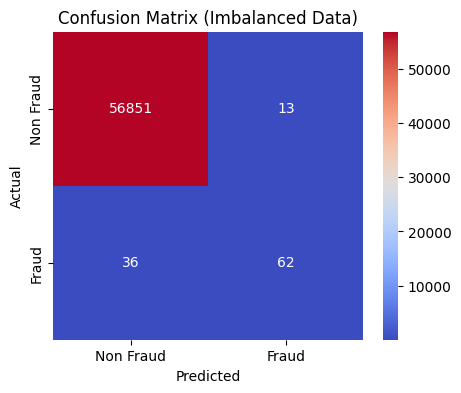

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='coolwarm',
    xticklabels=['Non Fraud','Fraud'],
    yticklabels=['Non Fraud','Fraud']
)

plt.title("Confusion Matrix (Imbalanced Data)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Apply Smote!!

In [ ]:
# SMOTE generates synthetic fraud samples

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


**Scaling of the smote data**

In [ ]:
# Scale SMOTE dataset

scaler_smote = StandardScaler()

X_train_smote_scaled = scaler_smote.fit_transform(X_train_smote)

X_test_smote_scaled = scaler_smote.transform(X_test)

Model Training

In [ ]:
model_smote = LogisticRegression(max_iter=5000)

model_smote.fit(X_train_smote_scaled, y_train_smote)

y_pred_smote = model_smote.predict(X_test_smote_scaled)

Evaluation

In [ ]:
print("Classification Report (After SMOTE)\n")

print(classification_report(y_test, y_pred_smote))

Classification Report (After SMOTE)

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.13      0.90      0.23        98

    accuracy                           0.99     56962
   macro avg       0.57      0.94      0.61     56962
weighted avg       1.00      0.99      0.99     56962



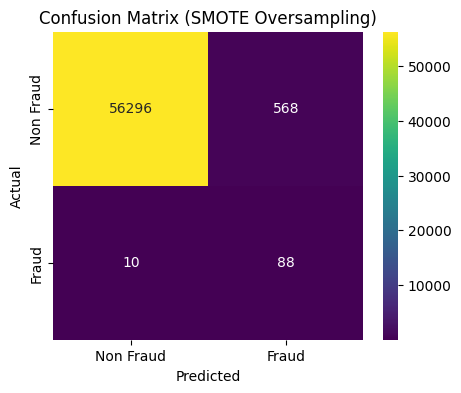

In [ ]:
cm_smote = confusion_matrix(y_test, y_pred_smote)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_smote,
    annot=True,
    fmt='d',
    cmap='viridis',
    xticklabels=['Non Fraud','Fraud'],
    yticklabels=['Non Fraud','Fraud']
)

plt.title("Confusion Matrix (SMOTE Oversampling)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Apply Random Undersampling

In [ ]:
# Undersampling removes majority class samples

undersample = RandomUnderSampler(random_state=42)

X_train_under, y_train_under = undersample.fit_resample(X_train, y_train)

print("Before Undersampling:")
print(y_train.value_counts())

print("\nAfter Undersampling:")
print(y_train_under.value_counts())

Before Undersampling:
Class
0    227451
1       394
Name: count, dtype: int64

After Undersampling:
Class
0    394
1    394
Name: count, dtype: int64


**Feature Scaling of undersampled data**

In [ ]:
# Scale undersampled dataset

scaler_under = StandardScaler()

X_train_under_scaled = scaler_under.fit_transform(X_train_under)

X_test_under_scaled = scaler_under.transform(X_test)

Model Training

In [ ]:
model_under = LogisticRegression(max_iter=5000)

model_under.fit(X_train_under_scaled, y_train_under)

y_pred_under = model_under.predict(X_test_under_scaled)

Evaluation

In [ ]:
print("Classification Report (After Undersampling)\n")

print(classification_report(y_test, y_pred_under))

Classification Report (After Undersampling)

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.05      0.92      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.94      0.54     56962
weighted avg       1.00      0.97      0.98     56962



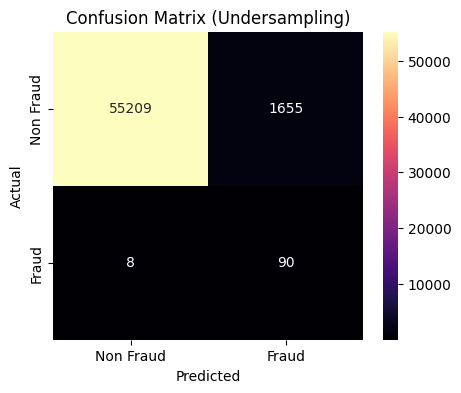

In [ ]:
cm_under = confusion_matrix(y_test, y_pred_under)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_under,
    annot=True,
    fmt='d',
    cmap='magma',
    xticklabels=['Non Fraud','Fraud'],
    yticklabels=['Non Fraud','Fraud']
)

plt.title("Confusion Matrix (Undersampling)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Bar Graph to compare

**Accuracy**

In [ ]:
acc_imbalanced = 0.99
acc_smote = 0.99
acc_under = 0.97

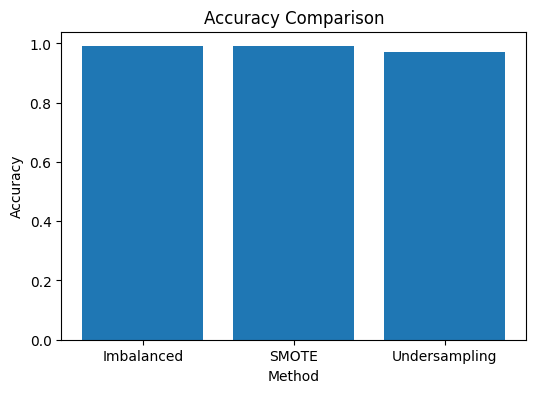

In [ ]:
methods = ['Imbalanced', 'SMOTE', 'Undersampling']

accuracy_values = [acc_imbalanced, acc_smote, acc_under]

plt.figure(figsize=(6,4))

plt.bar(methods, accuracy_values)

plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Method")

plt.show()

**Precision**

In [ ]:
prec_imbalanced= 0.91
prec_smote = 0.57
prec_under = 0.53

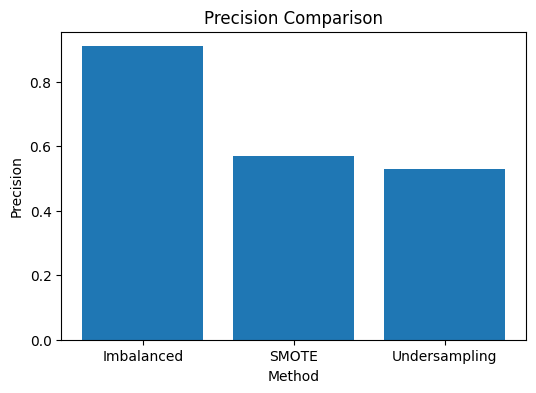

In [ ]:
precision_values = [prec_imbalanced, prec_smote, prec_under]

plt.figure(figsize=(6,4))

plt.bar(methods, precision_values)

plt.title("Precision Comparison")
plt.ylabel("Precision")
plt.xlabel("Method")

plt.show()

**Recall**

In [ ]:
rec_imbalanced=0.82
rec_smote= 0.94
rec_under=0.94

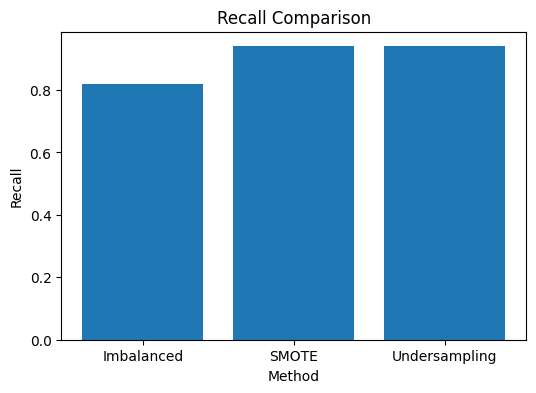

In [ ]:
recall_values = [rec_imbalanced, rec_smote, rec_under]

plt.figure(figsize=(6,4))

plt.bar(methods, recall_values)

plt.title("Recall Comparison")
plt.ylabel("Recall")
plt.xlabel("Method")

plt.show()